<a href="https://colab.research.google.com/github/CMDDclass/MS697-material/blob/main/1_GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<br><br>
<font size='6'><b>AI-driven Materials Development</b></font><br><br>

In this notebook, we'll use a GPU for faster model training.

To enable the GPU:

1. Navigate to Runtime.

2. Select Change runtime type.

3. Choose T4 GPU from the dropdown menu.

4. Click Save.

# Generative Adversarial Networks (GAN)



This notebook was prepared with reference to the Machine Learning course materials by and Seungchul Lee (KAIST).

# 1. Discriminative Model v.s. Generative Model

- Discriminative model



<br><br>
<center>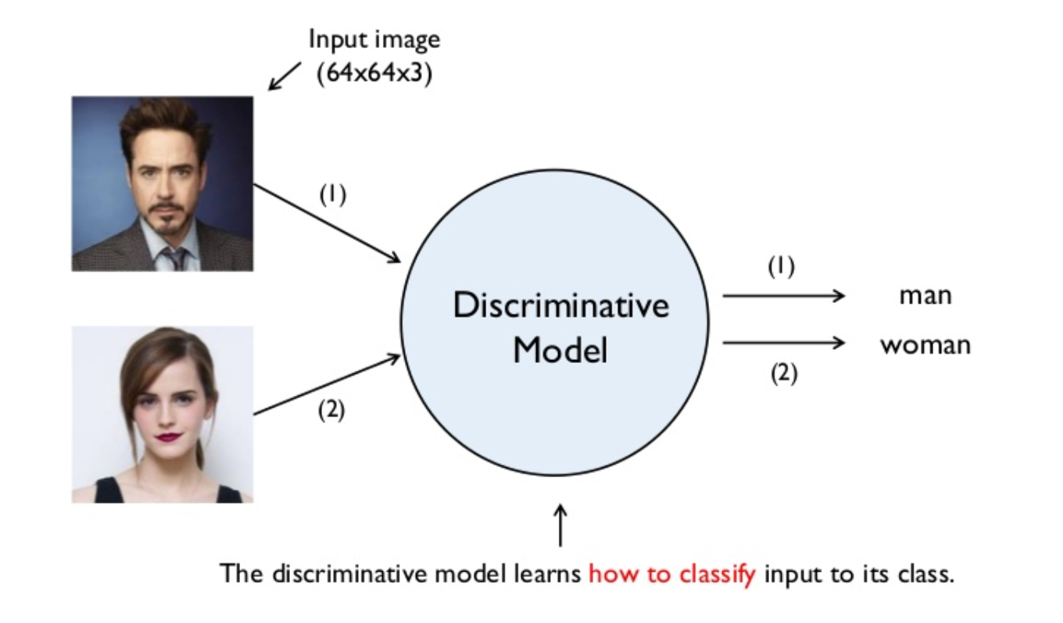</center>
<br>




- Cenerative model



<br>
<center>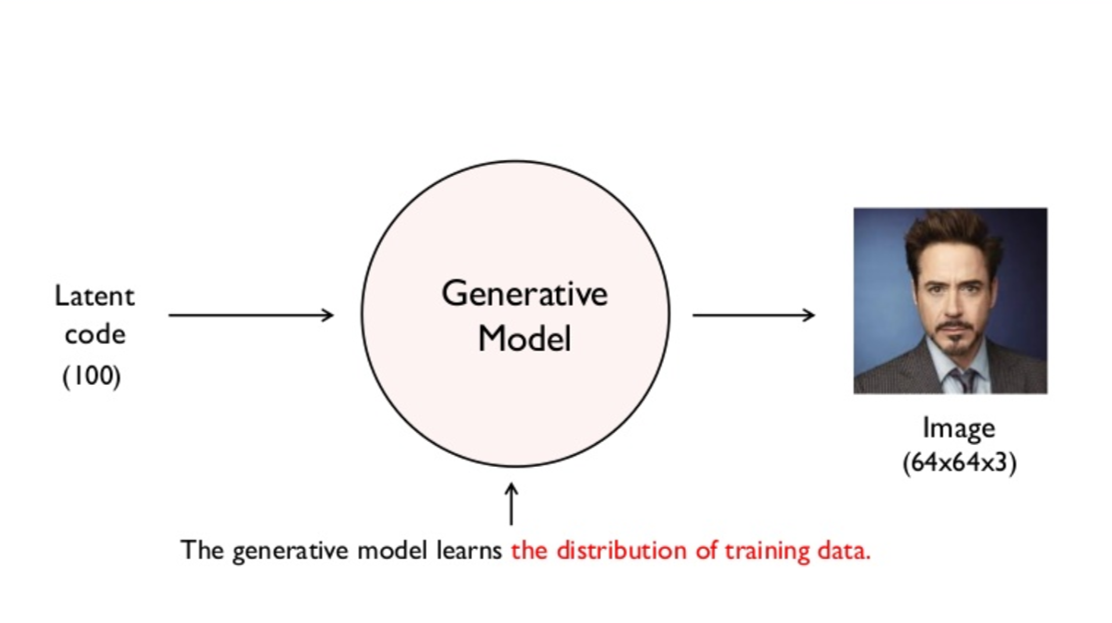</center>
<br>


# 2. Density Function Estimation

- Probability



<center>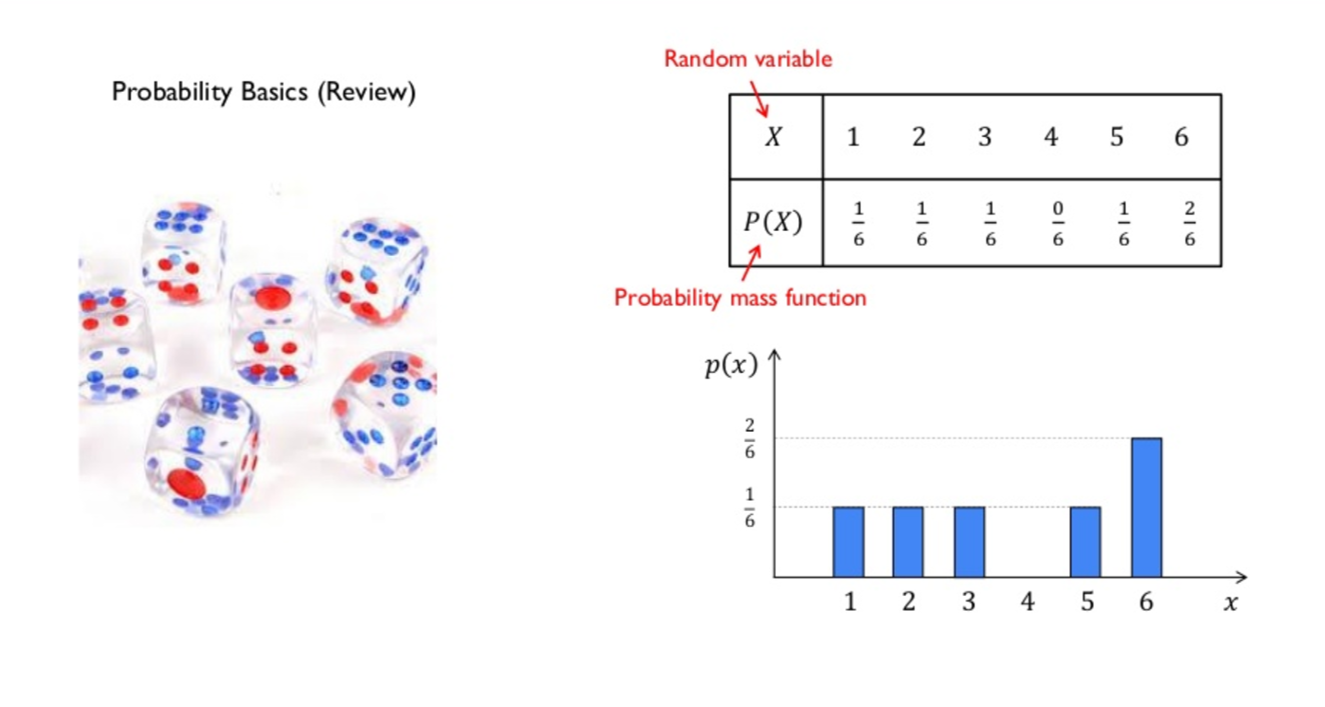</center>








- What if $x$ is actual images in the training data? At this point, $x$ can be represented as a (for example) $64\times 64 \times 3$ dimensional vector.
    - the following images are some realizations (samples) of $64\times 64 \times 3$ dimensional space



<center>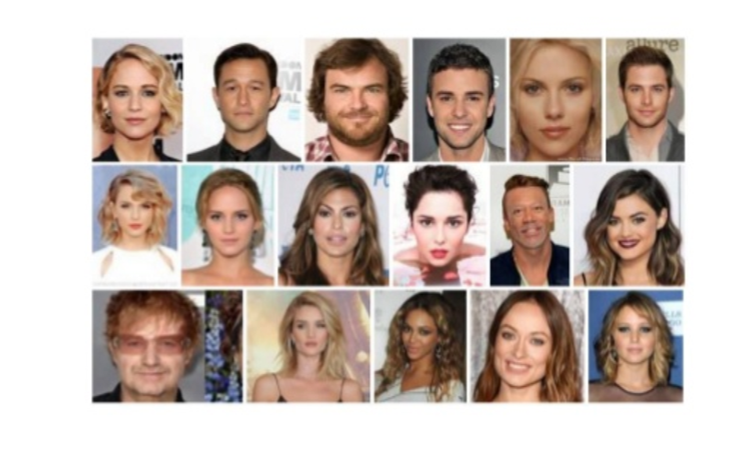</center>


- Probability density function estimation problem




<center>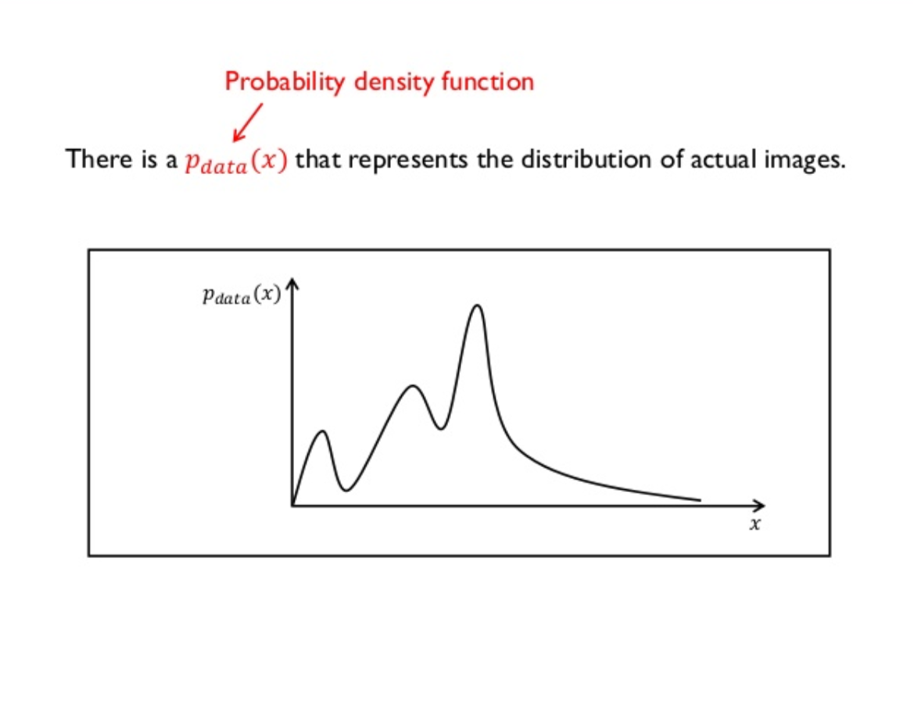</center>


<center>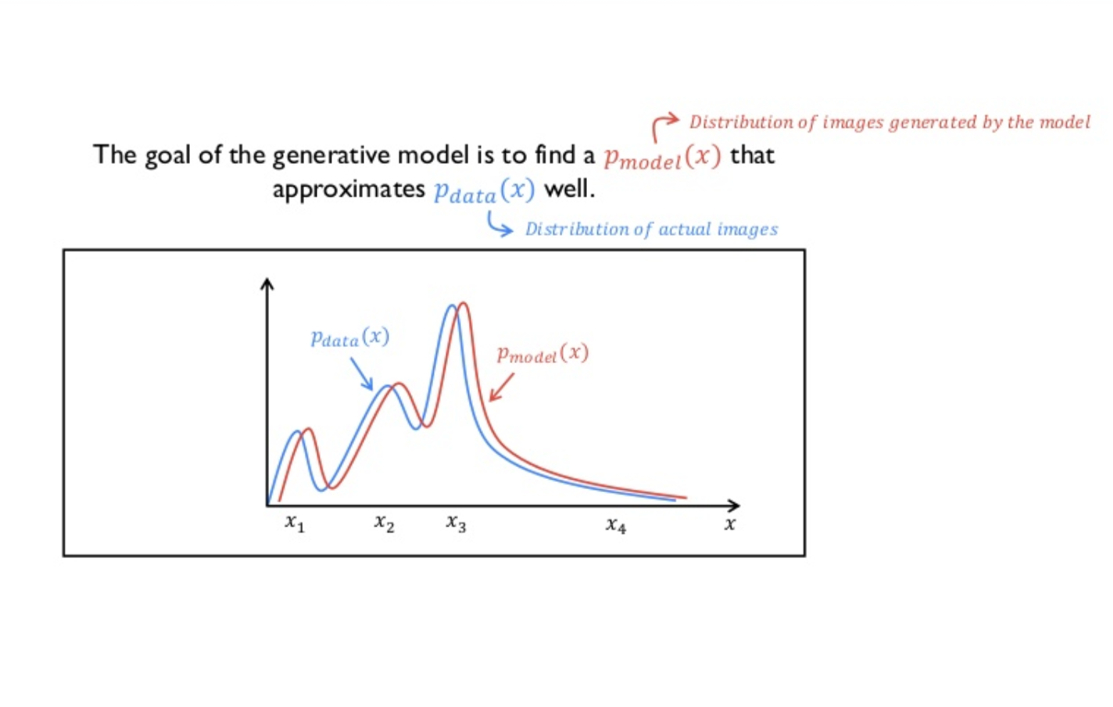</center>




- If $P_{\text{model}}(x)$ can be estimated as close to $P_{\text{data}}(x)$, then data can be generated by sampling from $P_{\text{model}}(x)$.

    - Note: Kullback–Leibler Divergence is a kind of distance measure between two distributions


- Learn determinstic transformation via a neural network
    - Start by sampling the code vector $z$ from a simple, fixed distribution such as a uniform distribution or a standard Gaussian $\mathcal{N}(0,I)$
    - Then this code vector is passed as input to a deterministic generator network $G$, which produces an output sample $x=G(z)$
    - This is how a neural network plays in a generative model (as a nonlinear mapping to a target probability density function)




<br>
<center>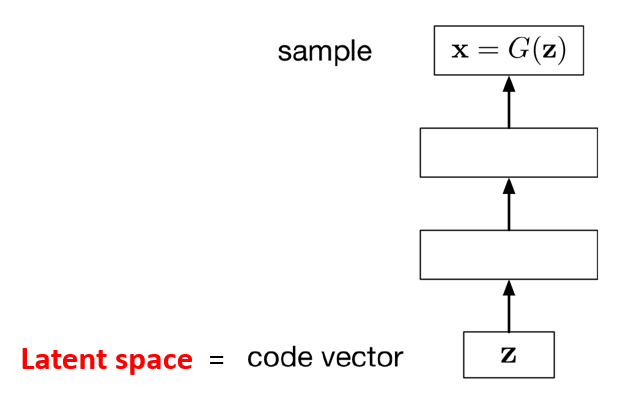</center>
<br>





- An example of a generator network which encodes a univariate distribution with two different modes


<br><br>
<center>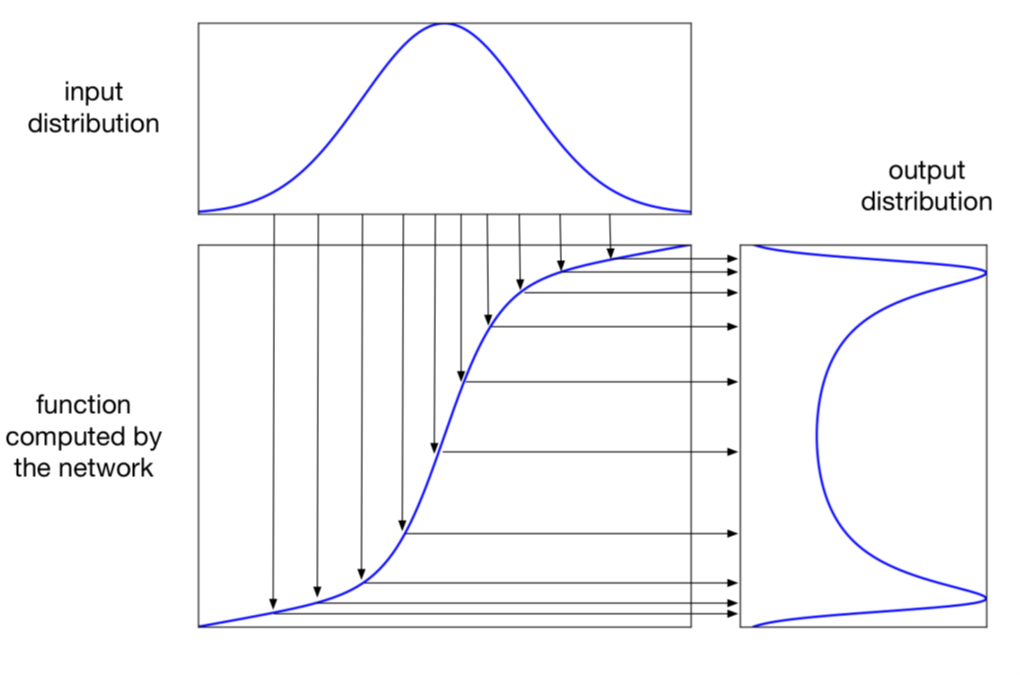</center>


- Generative model of high dimensional space


<center>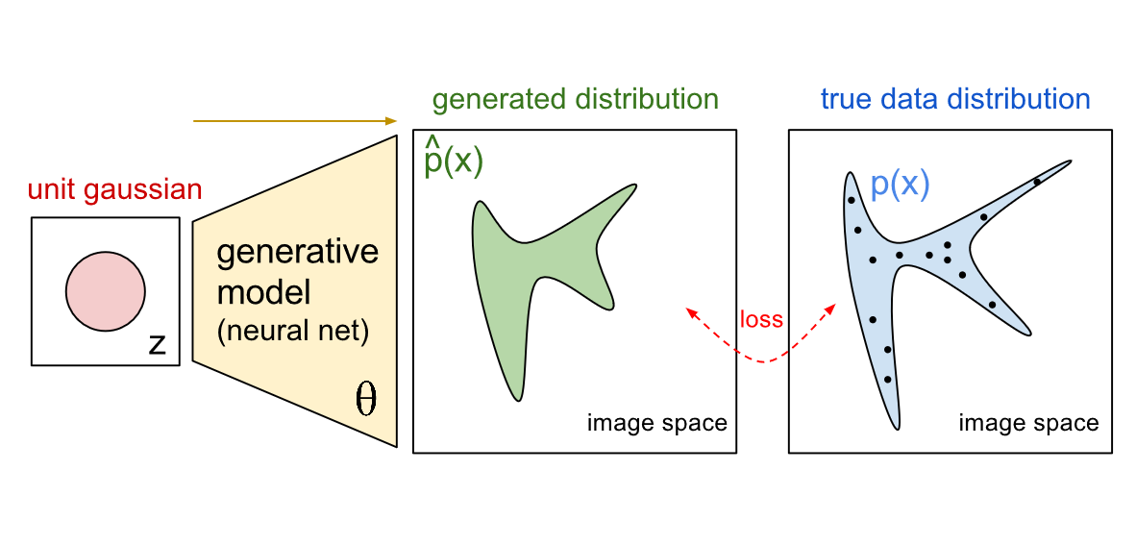</center>




- Generative model of images
    - learn a function which maps independent, normally-distributed $z$ values to whatever latent variables might be needed to the model, and then map those latent variables to $x$ (as images)
    - first few layers to map the normally distributed $z$ to the latent values
    - then, use later layers to map those latent values to an image


<br>
<center>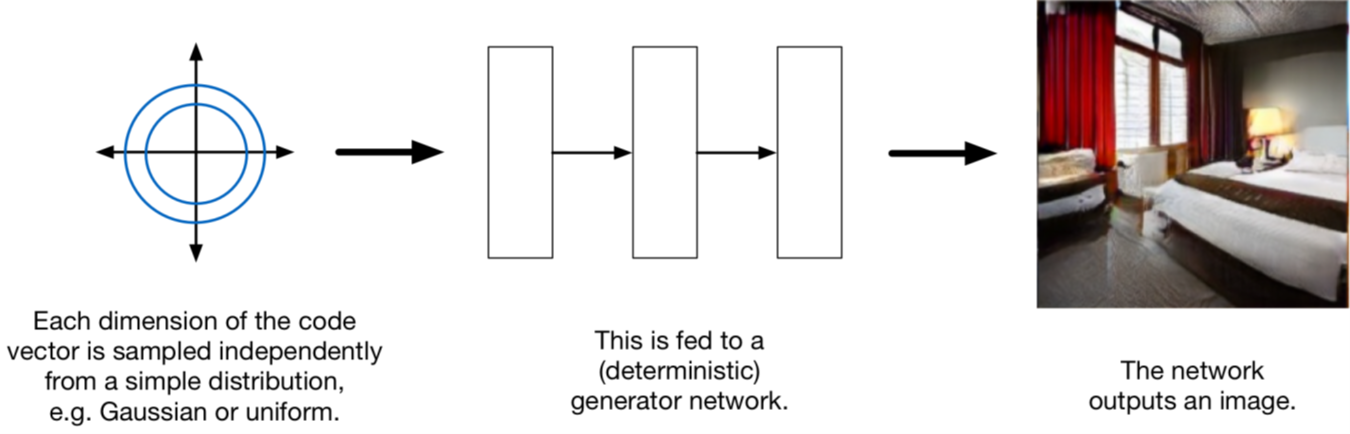</center>
<br>

# 3. Generative Adversarial Networks (GAN)

- In generative modeling, we'd like to train a network that models a distribution, such as a distribution over images.

- GANs do not work with any explicit density function !

- Instead, take game-theoretic approach

## 3.1. Adversarial Nets Framework

- One way to judge the quality of the model is to sample from it.
    
- Model to produce samples which are indistinguishable from the real data, as judged by a discriminator network whose job is to tell real from fake




<br><br>
<center>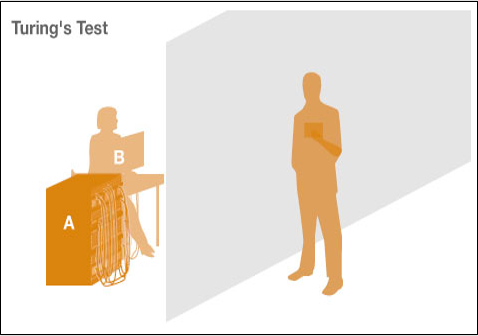</center>
<br>



<br>
<center>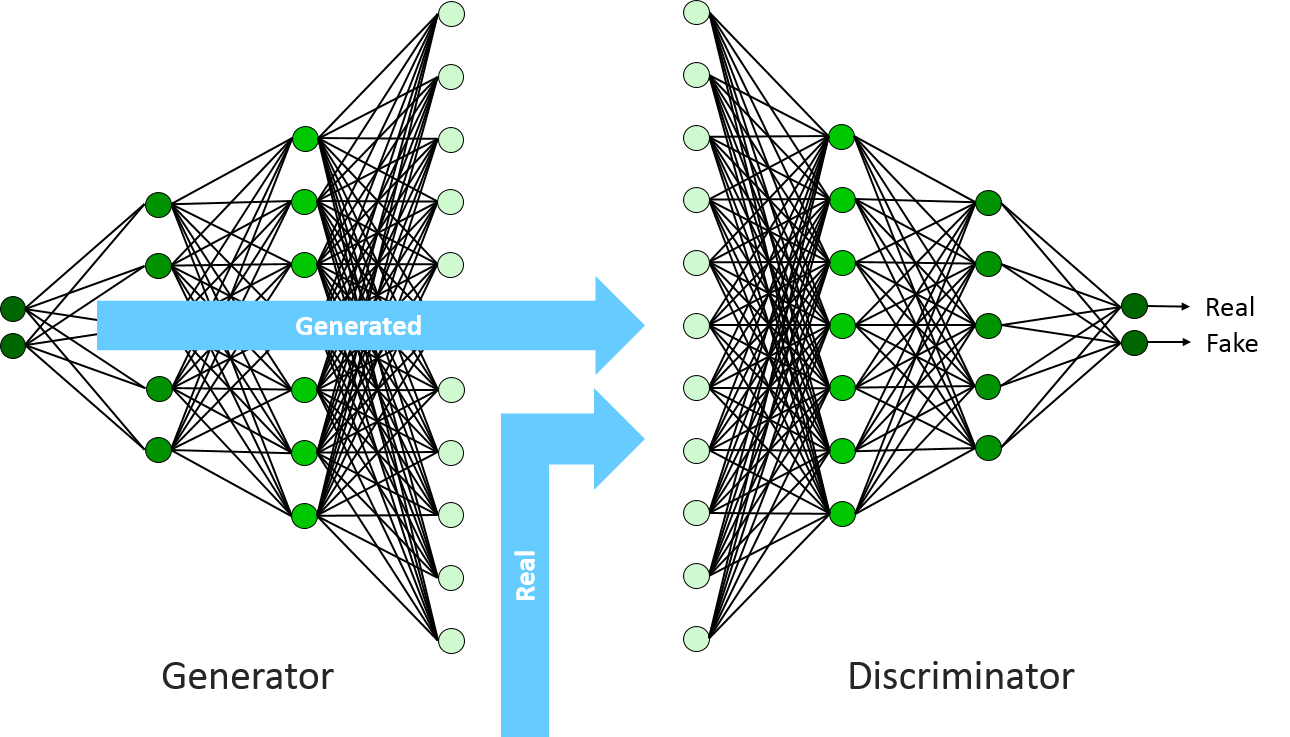</center>





- The idea behind Generative Adversarial Networks (GANs): train two different networks



<br>
<center>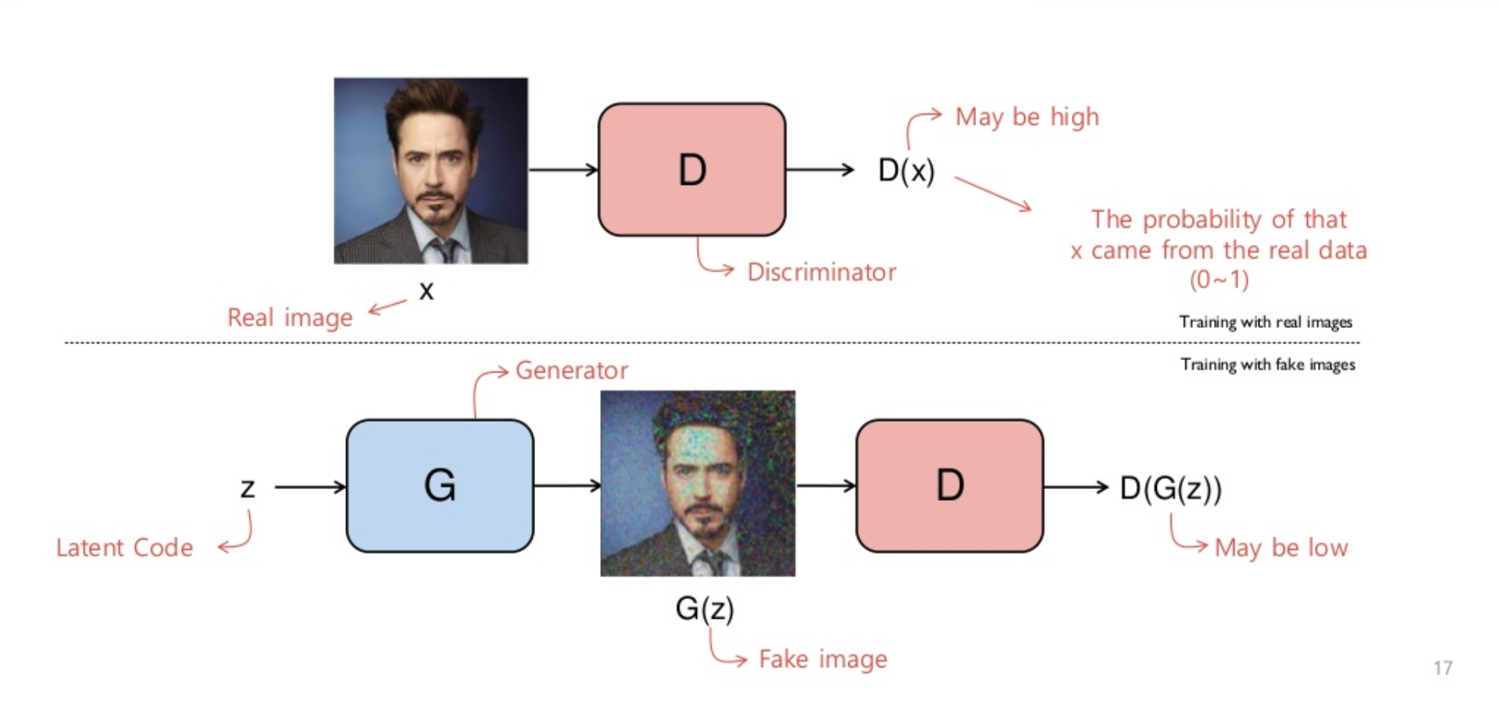</center>        



- Discriminator network: try to distinguish between real and fake data



<br>
<center>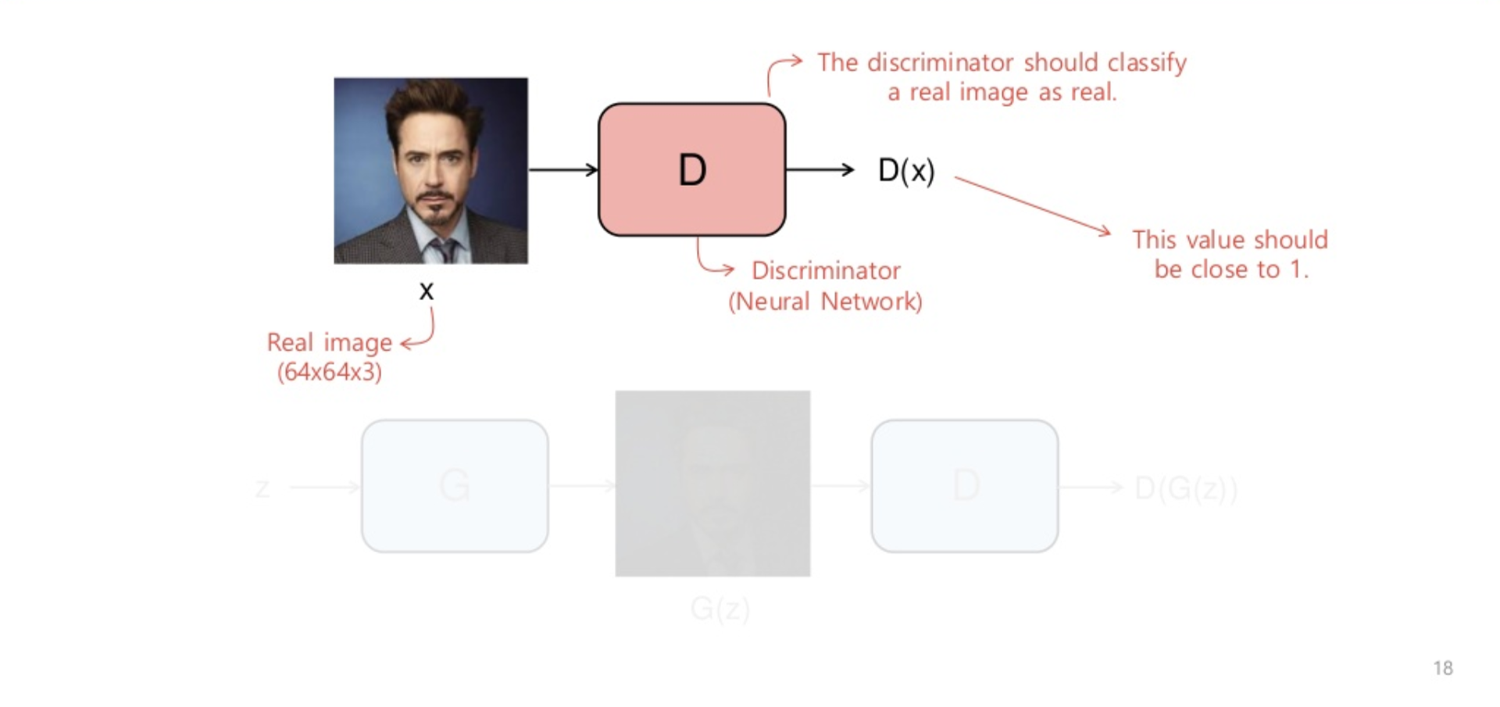</center>




<center>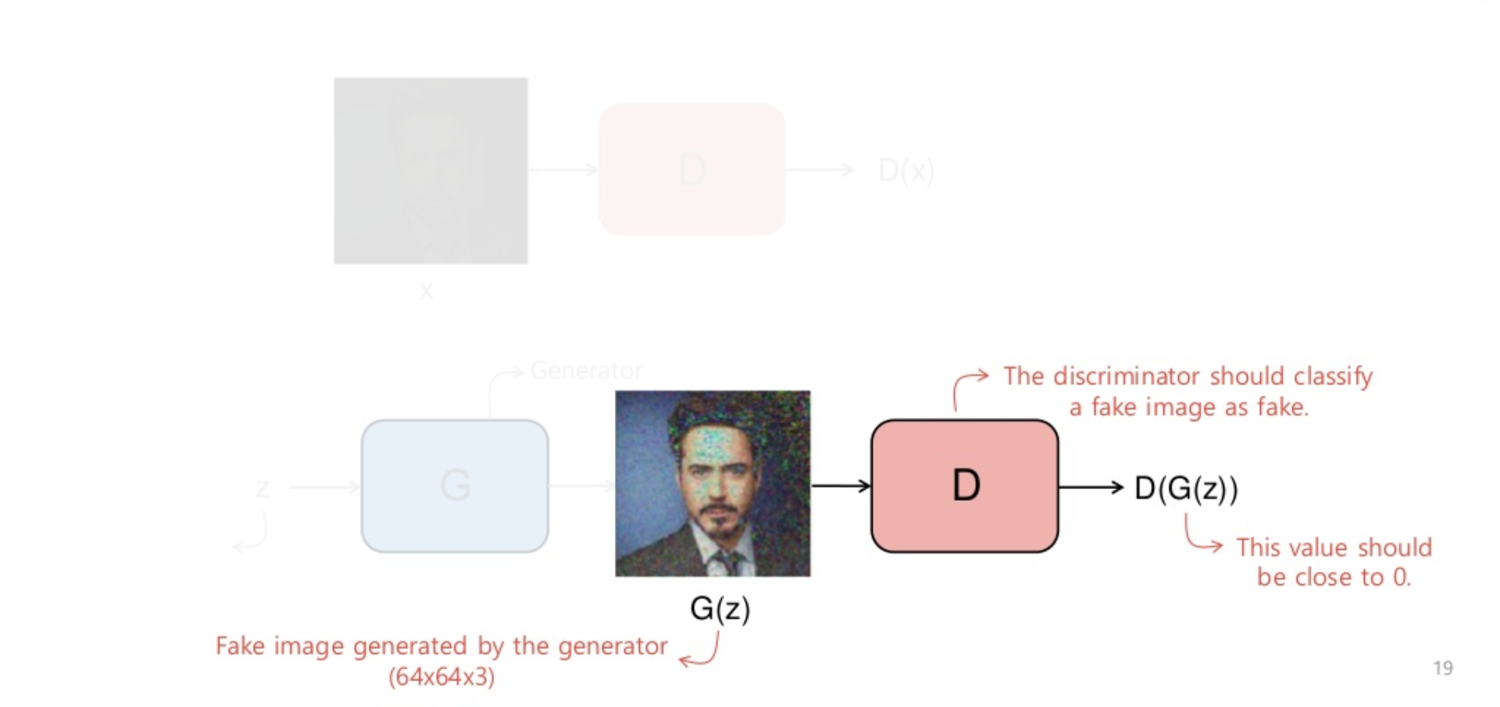</center>



- Generator network: try to produce realistic-looking samples to fool the discriminator network



<br>
<center>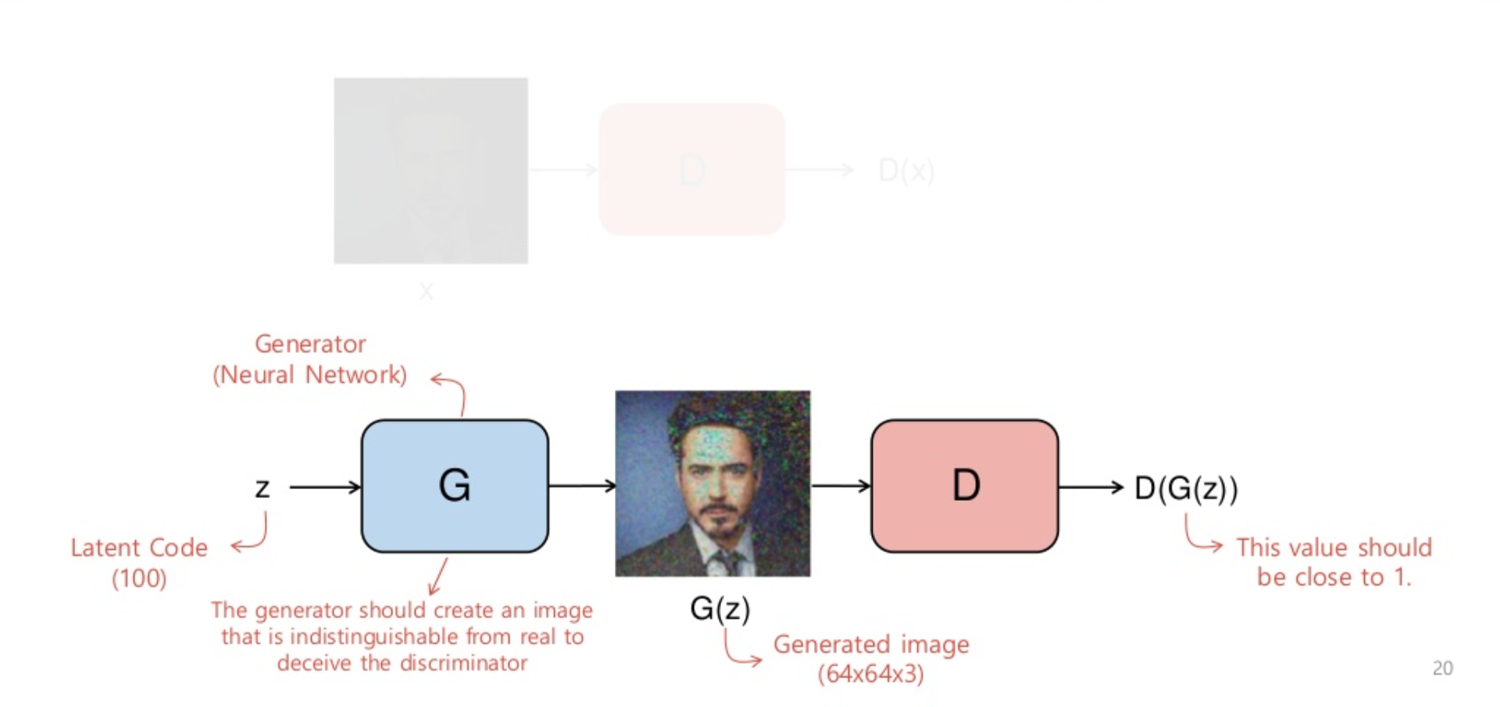</center>   




## 3.2. Objective Function of GAN

- Think about a logistic regression classifier (or cross entropy loss $(h(x),y)$)

<br>
$$\text{loss} = -y \log h(x) - (1-y) \log (1-h(x))$$


- To train the discriminator



<br>
<center>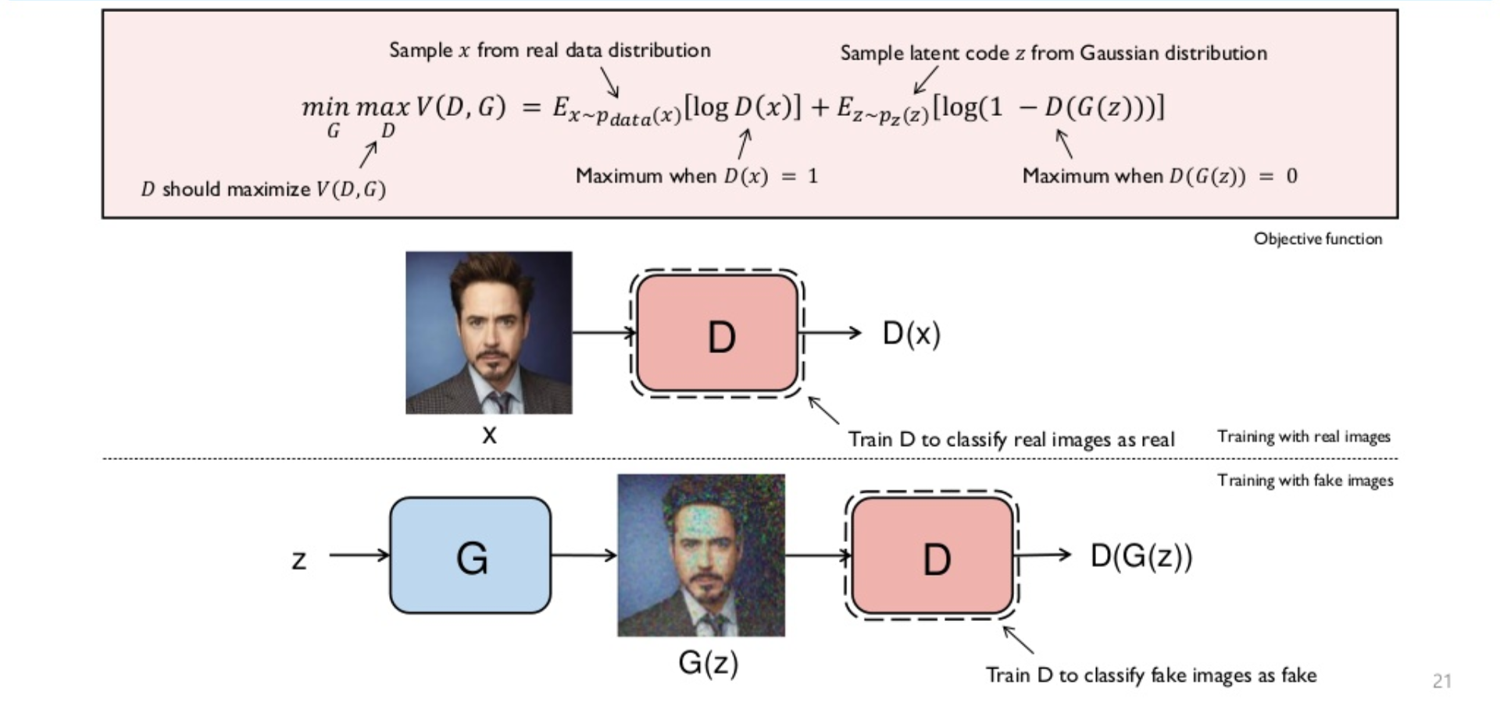</center>




- To train the generator


<br>
<center>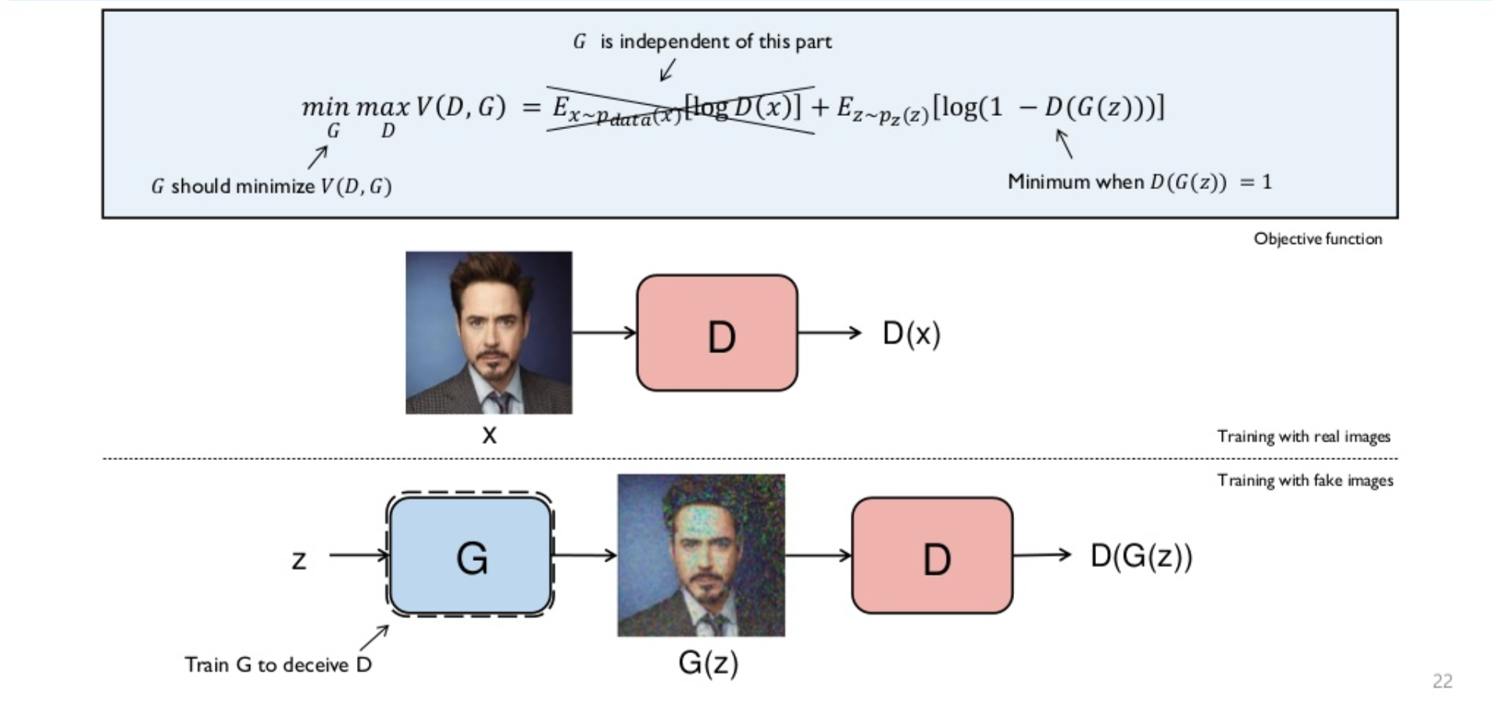</center>

- Non-Saturating Game when the generator is trained

- Early in learning, when $G$ is poor, $D$ can reject samples with high confidence because they are clearly different from the training data. In this case, $\log(1-D(G(z)))$ saturates.


<br>
<center>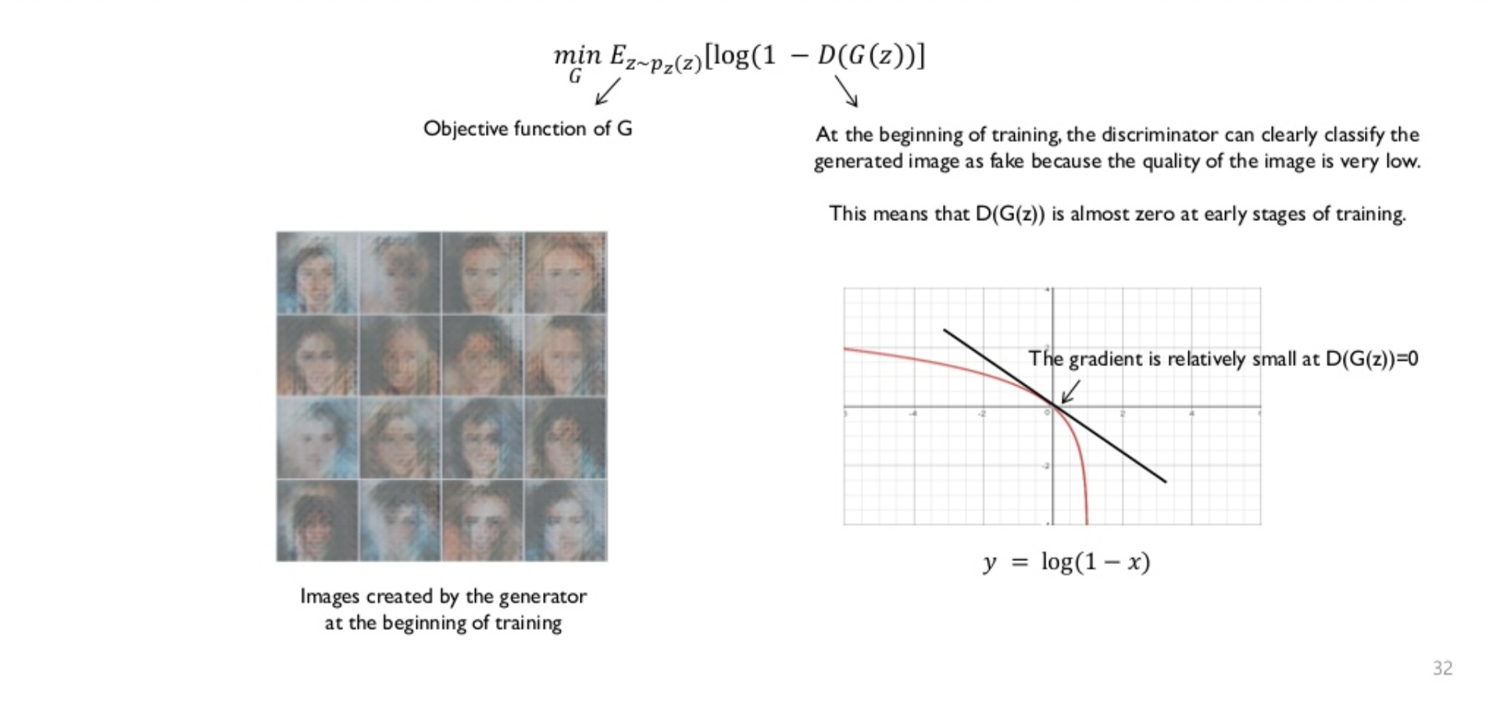</center>
<br>


- Rather than training $G$ to minimize $\log(1-D(G(z)))$ we can train $G$ to maximize $\log D(G(z))$. This objective function provides much stronger gradients early in learning.

<center>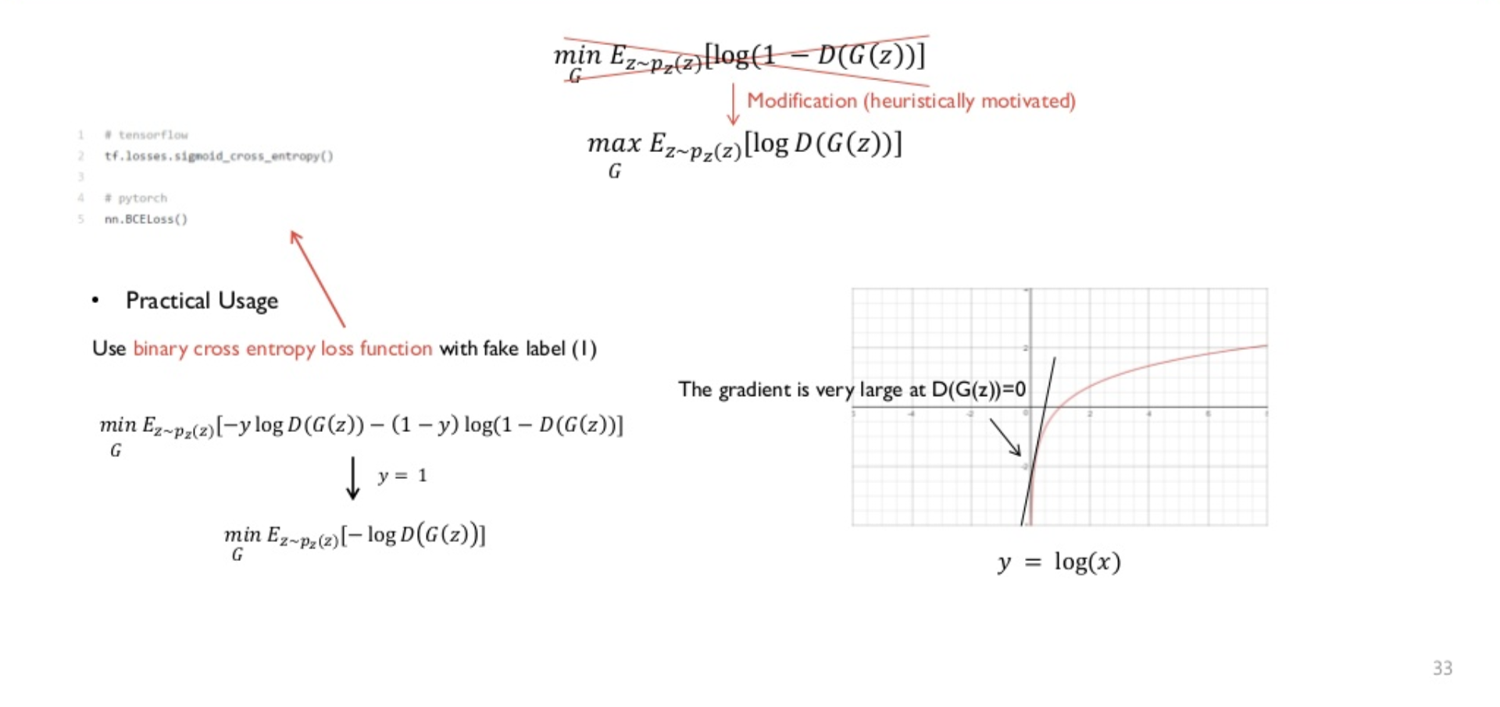</center>






## 3.3. Soving a MinMax Problem

<br>

Step 1: Fix $G$ and perform a gradient step to

<br>

$$\max_{D} E_{x \sim p_{\text{data}}(x)}\left[\log D(x)\right]  + E_{z \sim p_{z}(z)}\left[\log (1-D(G(z)))\right]$$

<br>

Step 2: Fix $D$ and perform a gradient step to

<br>

$$\max_{G} E_{z \sim p_{z}(z)}\left[\log D(G(z))\right]$$

<br>

OR

<br>

Step 1: Fix $G$ and perform a gradient step to

<br>

$$\min_{D} E_{x \sim p_{\text{data}}(x)}\left[-\log D(x)\right]  + E_{z \sim p_{z}(z)}\left[-\log (1-D(G(z)))\right]$$

<br>

Step 2: Fix $D$ and perform a gradient step to

<br>

$$\min_{G} E_{z \sim p_{z}(z)}\left[-\log D(G(z))\right]$$

# 4. GAN with MNIST

## 4.1. GAN Implementation

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.utils import plot_model

In [ ]:
!nvidia-smi
tf.config.list_physical_devices("GPU")

In [ ]:
LATENT_DIM = 100
BATCH_SIZE = 128
LABEL_SMOOTH = 0.9
D_STEPS = 2
N_ITER = 4000
LR = 2e-4
BETA_1 = 0.5

In [ ]:
def make_noise(samples):
    return np.random.normal(0, 1, [samples, 100])

def plot_generated_images(generator, samples=16):
    noise = make_noise(samples)
    generated_images = generator.predict(noise)
    generated_images = generated_images.reshape(samples, 28, 28)

    plt.figure(figsize=(6, 6))
    for i in range(samples):
        plt.subplot(4, 4, i + 1)
        plt.imshow(generated_images[i], cmap='gray', interpolation='nearest')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
def show_grid(imgs, grid=(4,4), fname=None, title=None, image_size=28):
    imgs = np.asarray(imgs)

    # (N, H, W, 1) → (N, H, W)
    if imgs.ndim == 4 and imgs.shape[-1] == 1:
        imgs = imgs[..., 0]

    # (N, 784) → (N, 28,28)
    if imgs.ndim == 2 and imgs.shape[1] == image_size * image_size:
        imgs = imgs.reshape(-1, image_size, image_size)

    if imgs.ndim != 3:
        raise ValueError(f"Expect (N,H,W) or (N,784), got {imgs.shape}")

    r, c = grid
    canvas = np.vstack([
        np.hstack([imgs[i*c + j] for j in range(c)])
        for i in range(r)
    ])

    plt.figure(figsize=(c, r))
    plt.axis('off')
    if title: plt.title(title)
    plt.imshow(canvas, cmap='gray', vmin=0, vmax=1)
    if fname:
        plt.savefig(fname, bbox_inches='tight', pad_inches=0)
    plt.show()
(train_x, train_y), _ = tf.keras.datasets.mnist.load_data()

print('train_images(0~9)', train_x.shape)

train_x = train_x[np.where(train_y == 2)]
train_x = train_x/255.0
train_x = train_x.reshape(-1, 784)


print('train_iamges(2) :', train_x.shape)
show_grid(train_x[:16], grid=(4,4), title="MNIST Digit 2 Samples")


train_dataset = tf.data.Dataset.from_tensor_slices(train_x) \
                               .shuffle(train_x.shape[0]) \
                               .batch(BATCH_SIZE, drop_remainder=True) \
                               .repeat()
train_iter = iter(train_dataset)

In [ ]:
def build_generator():
    z = layers.Input(shape=(LATENT_DIM,))
    x = layers.Dense(256, use_bias=False)(z)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dense(512, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dense(784, activation='tanh')(x)
    return models.Model(z, x, name="generator")
generator = build_generator()
generator.summary()

In [ ]:
def build_discriminator():
    x_in = layers.Input(shape=(784,))
    x = layers.Dense(512)(x_in)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.3)(x)
    logits = layers.Dense(1)(x) # No activation (from_logits=True)
    return models.Model(x_in, logits, name="discriminator")
discriminator = build_discriminator()
discriminator.summary()

In [ ]:
plot_model(
    generator,
    show_shapes=True,
    show_layer_names=True,
    rankdir="TB",
    dpi=160
)


In [ ]:
plot_model(
    discriminator,
    show_shapes=True,
    show_layer_names=True,
    rankdir="TB",
    dpi=160
)


Step 1: Fix $G$ and perform a gradient step to

<br>

$$\min_{D} E_{x \sim p_{\text{data}}(x)}\left[-\log D(x)\right]  + E_{x \sim p_{z}(z)}\left[-\log (1-D(G(z)))\right]$$

<br>

Step 2: Fix $D$ and perform a gradient step to

<br>

$$\min_{G} E_{x \sim p_{z}(z)}\left[-\log D(G(z))\right]$$

In [ ]:
bce_loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)
d_optimizer = tf.keras.optimizers.Adam(learning_rate=LR, beta_1=BETA_1)
g_optimizer = tf.keras.optimizers.Adam(learning_rate=LR, beta_1=BETA_1)

In [ ]:
real_labels_smoothed = tf.ones([BATCH_SIZE, 1], dtype=tf.float32) * LABEL_SMOOTH
fake_labels = tf.zeros([BATCH_SIZE, 1], dtype=tf.float32)
g_target_labels = real_labels_smoothed

In [ ]:
@tf.function
def train_step_d(real_images):
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

    with tf.GradientTape() as tape:
        generated_images = generator(noise, training=True)

        real_logits = discriminator(real_images, training=True)
        fake_logits = discriminator(generated_images, training=True)

        d_loss_real = bce_loss(real_labels_smoothed, real_logits)
        d_loss_fake = bce_loss(fake_labels, fake_logits)
        d_loss = d_loss_real + d_loss_fake

    grads = tape.gradient(d_loss, discriminator.trainable_variables)
    d_optimizer.apply_gradients(zip(grads, discriminator.trainable_variables))
    return d_loss

In [ ]:
@tf.function
def train_step_g():
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

    with tf.GradientTape() as tape:
        generated_images = generator(noise, training=True)
        combined_logits = discriminator(generated_images, training=False)

        g_loss = bce_loss(g_target_labels, combined_logits)

    grads = tape.gradient(g_loss, generator.trainable_variables)
    g_optimizer.apply_gradients(zip(grads, generator.trainable_variables))
    return g_loss

In [ ]:
print("Training starts...")
for i in range(N_ITER):

    d_loss_avg = 0.0
    for _ in range(D_STEPS):
        real_images_batch = next(train_iter)
        d_loss = train_step_d(real_images_batch)
        d_loss_avg += d_loss

    g_loss = train_step_g()

    if i % 1000 == 0:
        d_loss_val = (d_loss_avg / D_STEPS).numpy()
        g_loss_val = g_loss.numpy()
        print(f"iter {i} | D: {d_loss_val:.4f} | G: {g_loss_val:.4f}")
        plot_generated_images(generator)


## 4.2. After Training


- After training, use the generator network to generate new data




<center>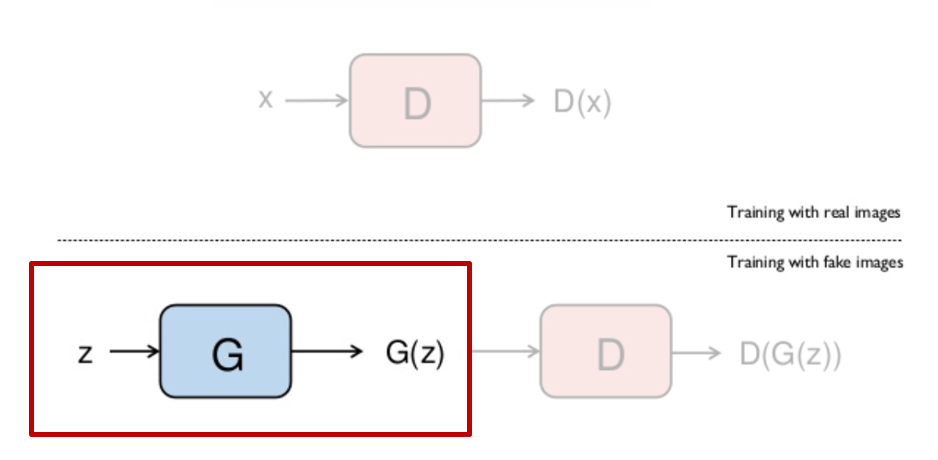</center>
<br>


In [ ]:
plot_generated_images(generator)

# Practice:  Generate a Specific Digit ("9") with a Standard GAN

Train a generator using the MNIST dataset and generate images of the digit 9.

### **Submit the following as your practice result:
• Generated "9" images (9 images)